## Анализ представленных данных (EDA) 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel('data/asset-v1.xlsx', index_col=0)
data.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data.shape

(1001, 213)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


In [5]:
data.isna().sum().sum()

36

In [6]:
data.isna().sum()[data.isna().sum() > 0]

MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
MinAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
dtype: int64

Всего в датасете 213 признаков, пропусков только 36, они распределены по 3 в 12 колонках.

In [7]:
# Посмотрим на количество строк, которые содержат хотя бы один пропуск
data[data.isna().any(axis=1)]

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
78,1127.094988,1127.094988,1.000000,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,...,0,0,0,0,0,0,0,0,0,0
79,25.171788,1878.491646,74.626866,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,...,0,0,0,0,0,0,0,0,0,0
80,1199.174968,1199.174968,1.000000,11.600528,11.600528,0.228349,-0.861204,0.286242,10.937500,250.175,...,1,0,0,0,0,0,0,0,0,0


In [8]:
data = data.dropna()
data.shape

(998, 213)

In [9]:
def num_variable_analysis(data, column, title):
    print(data[column].describe())
    fig, ax = plt.subplots(figsize = (17,2))
    ax = data[[column]].boxplot(vert = False, ax =ax)
    ax.set_title(f'Диаграмма размаха {title}')
    plt.show()
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[column][(data[column] < lower) | (data[column] > upper)]
    print (len(outliers), lower, upper)

In [10]:
def num_variable_visualization(data, column, title):
    data = data[column].plot(title=title, kind='hist', bins=25, grid=True, figsize=(10,6), color='skyblue', edgecolor='black')
    data.set_xlabel(column)
    data.set_ylabel(title)
    plt.show()

count     998.000000
mean      221.118757
std       400.510657
min         0.003517
25%        12.491340
50%        45.992006
75%       224.408630
max      4128.529377
Name: IC50, mM, dtype: float64


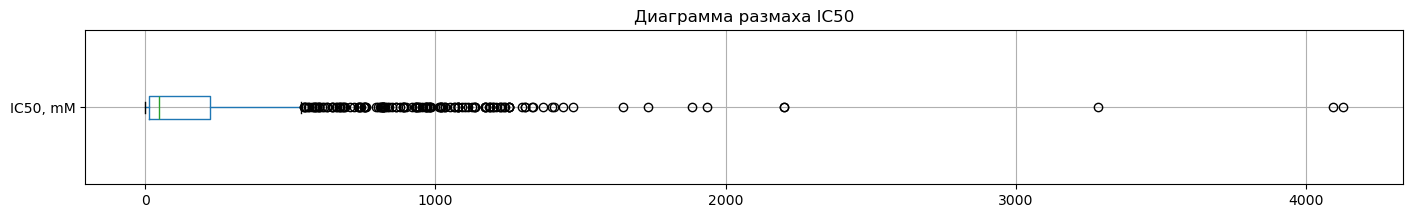

145 -305.3845959600004 542.2845656748658


In [11]:
num_variable_analysis(data, 'IC50, mM', 'IC50')

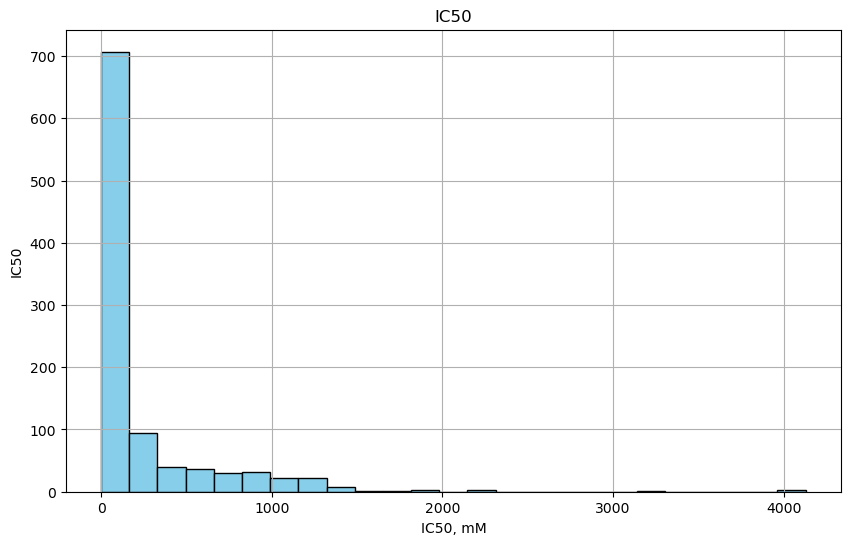

In [12]:
num_variable_visualization(data, 'IC50, mM', 'IC50')

Распределение сильно смещено вправо, много выбросов (145), лучше оставить их. Перед моделированием прологарифмируем данный признак.

count     998.000000
mean      586.668414
std       642.016454
min         0.700808
25%        99.999036
50%       408.793314
75%       891.770961
max      4538.976189
Name: CC50, mM, dtype: float64


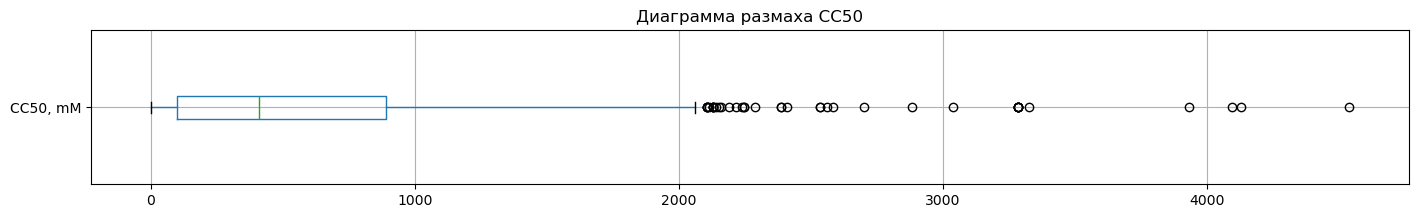

39 -1087.658852200291 2079.428848342164


In [13]:
num_variable_analysis(data, 'CC50, mM', 'CC50')

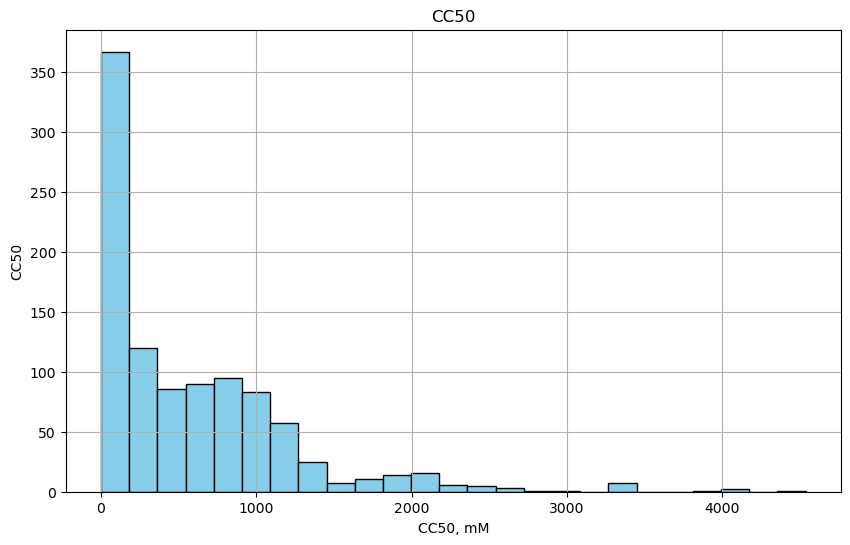

In [14]:
num_variable_visualization(data, 'CC50, mM', 'CC50')

Также наблюдается сильная правосторонняя асимметрия, но выбросов меньше (39). Данный признак тоже лучше прологарифмировать. 

count      998.000000
mean        72.650005
std        685.504279
min          0.011489
25%          1.457233
50%          3.856410
75%         16.525000
max      15620.600000
Name: SI, dtype: float64


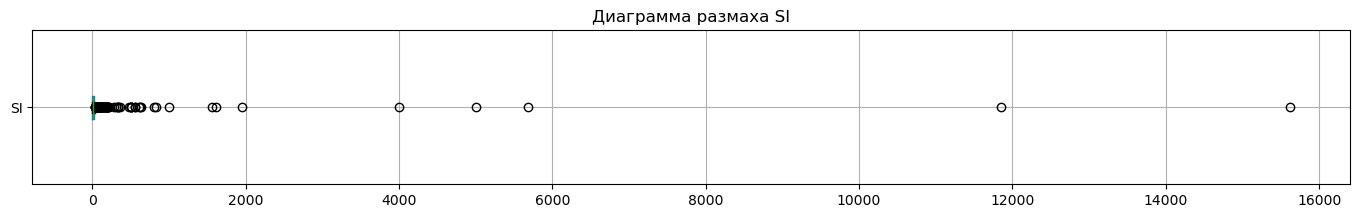

124 -21.14441747572816 39.1266504854369


In [15]:
num_variable_analysis(data, 'SI', 'SI')

In [16]:
data[data['SI'] > 10000]

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
773,0.021100,250.001758,11848.333333,11.284112,11.284112,0.021160,-0.986230,0.669590,26.250000,284.356,...,0,0,0,0,0,0,0,0,0,0
799,0.016004,249.999200,15620.600000,11.953988,11.953988,0.061346,-0.419485,0.691224,24.818182,312.410,...,0,0,0,0,0,0,0,0,0,0


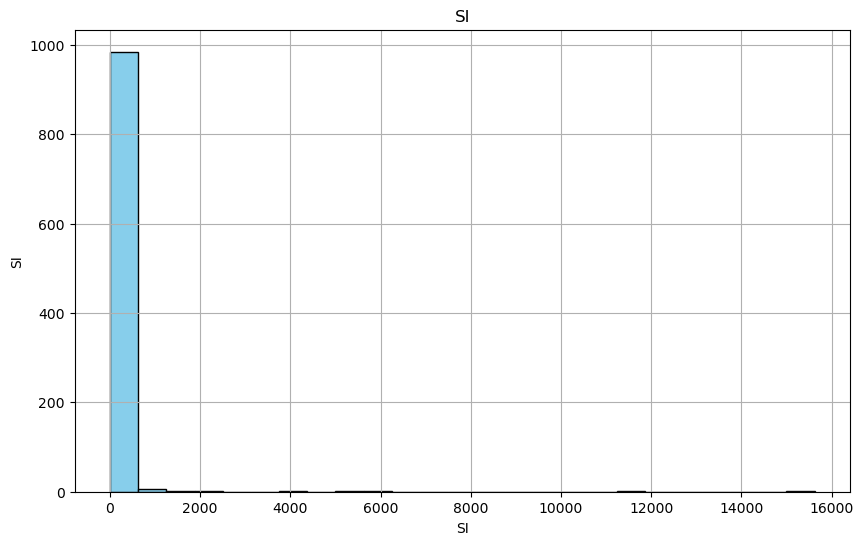

In [17]:
num_variable_visualization(data, 'SI', 'SI')

Распределение сильно скошено, оставим выбросы, но также прологарифмируем признак.

In [18]:
data['log_IC50'] = np.log10(data['IC50, mM'])
data['log_CC50'] = np.log10(data['CC50, mM'])
data['log_SI']   = np.log10(data['SI'])

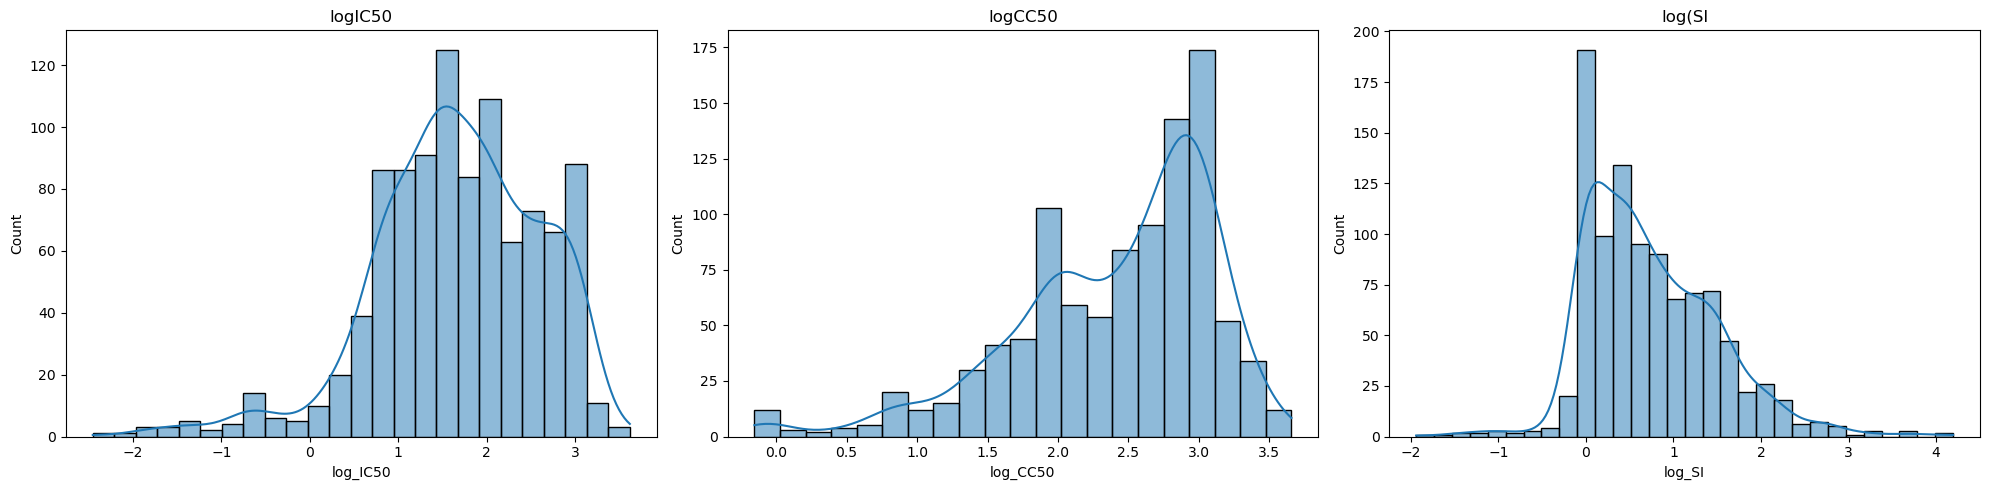

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20,5))
sns.histplot(data['log_IC50'], kde=True, ax=axes[0])
axes[0].set_title('logIC50')
sns.histplot(data['log_CC50'], kde=True, ax=axes[1])
axes[1].set_title('logCC50')
sns.histplot(data['log_SI'], kde=True, ax=axes[2])
axes[2].set_title('log(SI')
plt.tight_layout()
plt.show()

Логарифмированные признаки IC50, CC50 немного смещены влево. У SI наблюдается ярко выраженный пик в 0. Посмотрим на  корреляции с целевыми переменными.

In [20]:
target_columns = ['log_IC50', 'log_CC50', 'log_SI']
features = data.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'log_IC50', 'log_CC50', 'log_SI'])
corr_with_targets = data[target_columns + list(features.columns)].corr()[target_columns].drop(target_columns)

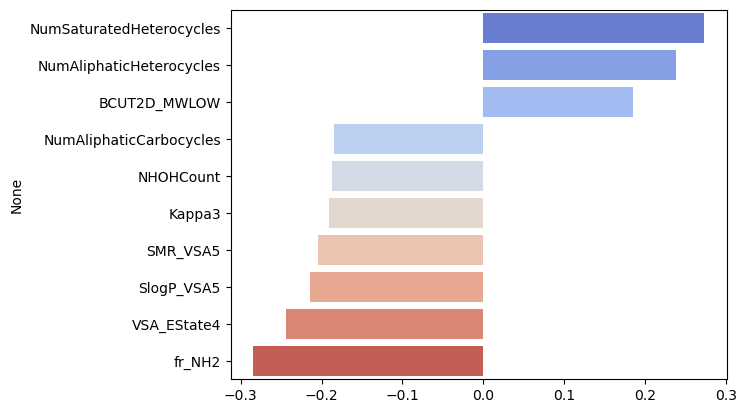

In [21]:
top_10_IC50 = corr_with_targets['log_IC50'].abs().sort_values(ascending=False).head(10)
top10_IC50_signed = corr_with_targets.loc[top_10_IC50.index, 'log_IC50'].sort_values(ascending=False) 
sns.barplot(y=top10_IC50_signed.index, x=top10_IC50_signed.values, hue=top10_IC50_signed.index, palette='coolwarm',legend=False);

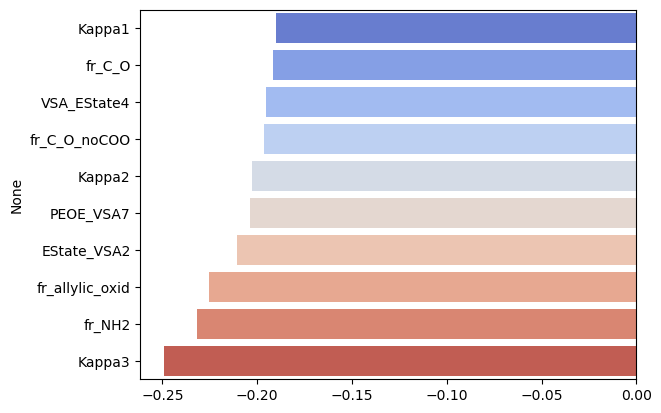

In [22]:
top_10_log_CC50 = corr_with_targets['log_CC50'].abs().sort_values(ascending=False).head(10)
top10_log_CC50_signed = corr_with_targets.loc[top_10_log_CC50.index, 'log_CC50'].sort_values(ascending=False) 
sns.barplot(y=top10_log_CC50_signed.index, x=top10_log_CC50_signed.values, hue=top10_log_CC50_signed.index, palette='coolwarm',legend=False);

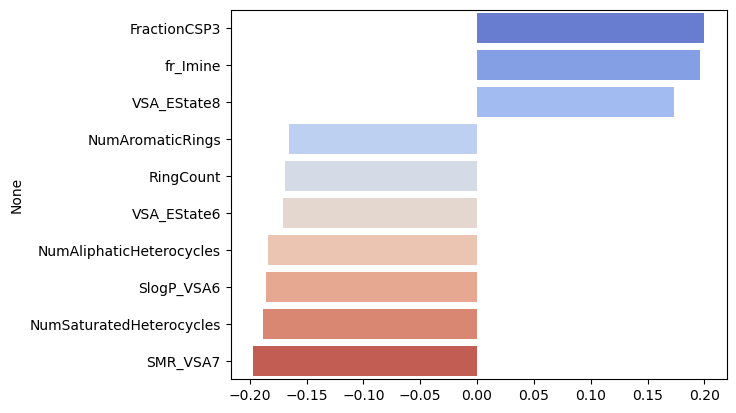

In [23]:
top_10_log_log_SI = corr_with_targets['log_SI'].abs().sort_values(ascending=False).head(10)
top10_log_log_SI_signed = corr_with_targets.loc[top_10_log_log_SI.index, 'log_SI'].sort_values(ascending=False) 
sns.barplot(y=top10_log_log_SI_signed.index, x=top10_log_log_SI_signed.values, hue=top10_log_log_SI_signed.index, palette='coolwarm',legend=False);

Для всех трех целевых переменных корреляции небольшие, не превышают 0.3. Есть пересечение признаков:  fr_NH2, Kappa3,  VSA_EState4, NumAliphaticHeterocycles, NumSaturatedHeterocycles.

Теперь построим матрицу корреляций для топ-20 (пересечение всех трех списков), проверим мультиколлинеарность.

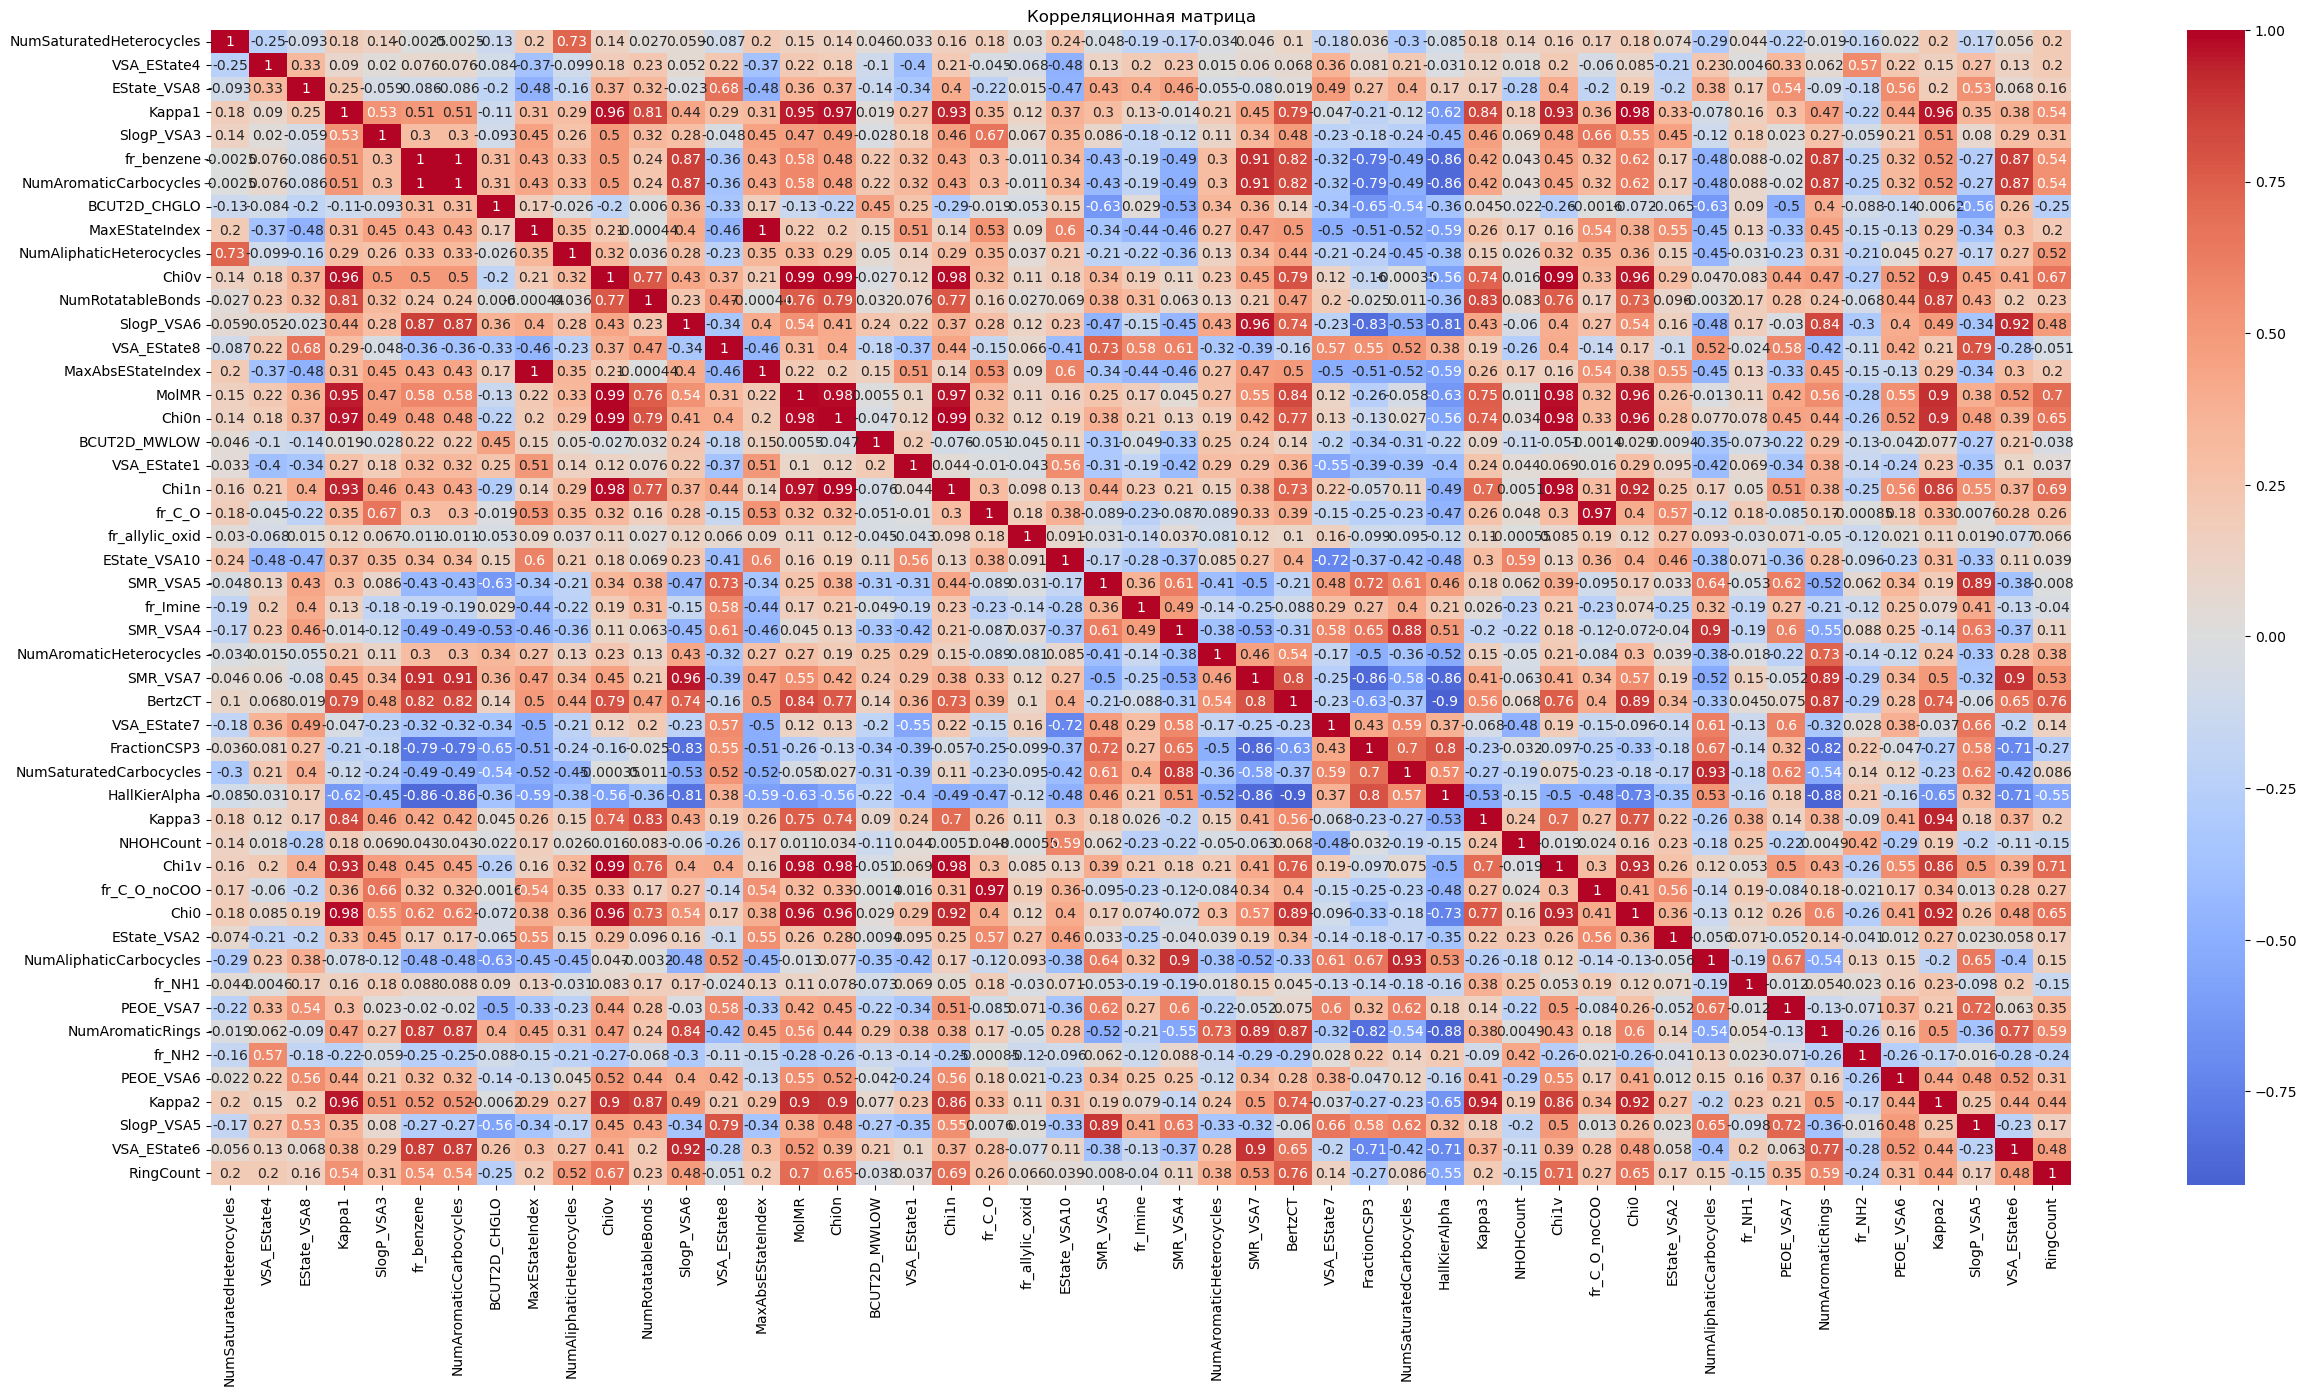

In [24]:
top_features = set()
for t in target_columns:
    top = corr_with_targets[t].abs().sort_values(ascending=False).head(20).index
    top_features.update(top)
top_features = list(top_features)

plt.figure(figsize=(30,15))
sns.heatmap(data[top_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

Получилось 49 признаков, можно заметить мультиколлениарность между некоторыми признаками, что может ухудшить работу моделей, удалим такие признаки.

In [28]:
corr = data[top_features].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if (upper[col] > 0.85).any()]
selected_features = [f for f in top_features if f not in to_drop]
len(selected_features)

30

В ходе выполнения EDA было обнаружено, что всего в датасете 213 признаков, пропусков только 36, и при этом они распределены по 3 в 12 колонках. Поэтому пропуски были удалены. Далее, для целевых переменных были построены диаграммы размаха и гистограммы. Выбросы решено было оставить, так как они могут демонстрировать редкие медицинские случаи. Все гистограммы целевых переменных были сильно смещены, поэтому (а также для уменьшения влияния выбросов) к данных признакам было применено логарифмирование. После были изучены корреляции, оказалось, что все целевые переменные имеют корреляцию не более 0.3, при этом есть пересечение признаков. После избавления от мультиколлениарности осталось 30 признаков.

Целевые переменные:
IC50(Half Maximal Inhibitory Concentration) - концентрация вещества, при которой активность вируса подавляется на 50% (высокий показатель = нужно много веществ для подавления вируса, низкий = вещество эффективно уже при малой концетрации).
CC50(50% Cytotoxic Concentration) - концентрация вещества, при которой погибает 50% клеток (высокий показатель = вещество менее токсично, низкий = токсично даже в малом объеме).
SI(Selectivity Index) - индекс селективности препарата (СС50/IC50) (чем выше, тем лучше).

In [33]:
# Сохранение итогового датасета для моделирования
data['IC50_median'] = (data['IC50, mM'] > data['IC50, mM'].median()).astype(int)
data['CC50_median'] = (data['CC50, mM'] > data['CC50, mM'].median()).astype(int)
data['SI_median']   = (data['SI'] > data['SI'].median()).astype(int)
data['SI_8'] = (data['SI'] > 8).astype(int)

selected_columns = selected_features + ['log_IC50', 'log_CC50', 'log_SI', 'IC50, mM', 'CC50, mM', 'SI', 'IC50_median', 'CC50_median', 'SI_median', 'SI_8']

data_final = data[selected_columns]
data_final.to_csv('data/preprocessed_data.csv', index=False)